In [6]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

DB_PATH = "../../CCSMLDatabase.db"
OOD_CSV = "../../datasets/ood_datasets/ood_testset.csv"

conn = sqlite3.connect(DB_PATH)
db_df = pd.read_sql_query("SELECT smi FROM master_clean WHERE smi IS NOT NULL", conn)
conn.close()

ood_df = pd.read_csv(OOD_CSV)
ood_df = ood_df[ood_df["smi"].notna() & (ood_df["smi"].str.len() > 0)]

# Global style settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"], # Standard crisp fonts
    "axes.linewidth": 1.5,               # Thicker axis lines
    "axes.spines.top": False,            # Remove top spine
    "axes.spines.right": False,          # Remove right spine
    "xtick.major.width": 1.5,            # Match tick thickness to axis
    "ytick.major.width": 1.5,
    "xtick.direction": "out",            # Ticks point outside
    "ytick.direction": "out",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
})

print(f"CCSMLDatabase (master_clean): {len(db_df)} rows | OOD set (deduped): {len(ood_df)} rows")

CCSMLDatabase (master_clean): 66153 rows | OOD set (deduped): 5827 rows


# R1-#10: how OOD is the OOD test set, chemically?

`ood_testset.csv` has no subclass labels, so a breakdown of accuracy by exclusively-unseen subclass isn't possible from this file alone (real ClassyFire labels for its ~14k unique molecules would mean tens of thousands of sequential API calls -- not practical here).

`ood_testset.csv` is built by `build_ood_testset.py` (in `xulabs_ml/ood/`), which already removes exact `smi` overlap against `CCSMLDatabase.db`'s `master_clean` and filters out anything with nearest-neighbor Tanimoto similarity >= 0.85 to that same reference. So exact-match overlap here should already be at or near zero by construction -- what's left to check is the shape of the remaining similarity distribution, not whether overlap exists at all.

Nearest-neighbor Tanimoto similarity: for every OOD molecule, its maximum similarity to any molecule in `CCSMLDatabase.db`'s `master_clean` (same non-hashed Morgan fingerprint settings used throughout this analysis). A compound with no close analog in the database (low max similarity) is genuinely novel chemical space; a compound with a close analog (high max similarity), even without being an exact duplicate, isn't really testing generalization to new chemistry.

In [7]:
db_smi = db_df["smi"].drop_duplicates().reset_index(drop=True)
ood_smi = ood_df["smi"].drop_duplicates().reset_index(drop=True)

print(f"Unique CCSMLDatabase molecules: {len(db_smi)}")
print(f"Unique OOD molecules: {len(ood_smi)}")
print(f"Exact smi overlap: {len(set(db_smi) & set(ood_smi))}")

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, includeChirality=True)


def compute_fingerprints(smiles_series):
    fps = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        mol = Chem.AddHs(mol)
        fps.append(morgan_generator.GetSparseCountFingerprint(mol))
    return fps


db_fps = compute_fingerprints(db_smi)
ood_fps = compute_fingerprints(ood_smi)

Unique CCSMLDatabase molecules: 31286
Unique OOD molecules: 3154
Exact smi overlap: 0


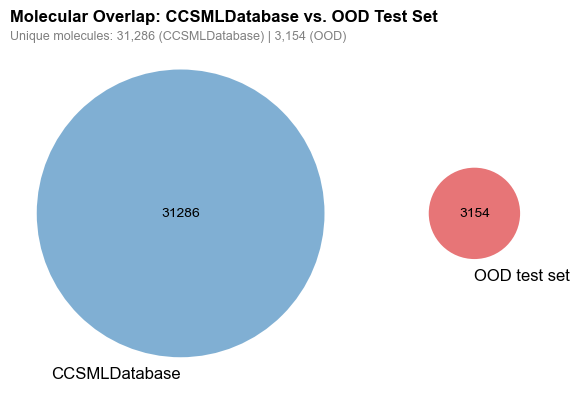

In [8]:
from matplotlib_venn import venn2

fig, ax = plt.subplots(figsize=(6, 5))
venn2(
    subsets=(len(set(db_smi) - set(ood_smi)), len(set(ood_smi) - set(db_smi)), len(set(db_smi) & set(ood_smi))),
    set_labels=("CCSMLDatabase", "OOD test set"),
    set_colors=("#2c7bb6", "#d7191c"),
    alpha=0.6,
    ax=ax,
)

ax.set_title("Molecular Overlap: CCSMLDatabase vs. OOD Test Set", loc="left", fontweight="bold", pad=15)
ax.text(0, 1.01, f"Unique molecules: {len(db_smi):,} (CCSMLDatabase) | {len(ood_smi):,} (OOD)",
        transform=ax.transAxes, fontsize=9, color="gray")

plt.tight_layout()
plt.show()

In [4]:
NEAR_DUPLICATE_THRESHOLD = 0.70

nn_similarity = np.array([
    max(DataStructs.BulkTanimotoSimilarity(ood_fp, db_fps)) for ood_fp in ood_fps
])

print(f"Nearest-neighbor Tanimoto similarity to CCSMLDatabase | mean: {nn_similarity.mean():.4f} | median: {np.median(nn_similarity):.4f}")
print(
    f"OOD molecules with a near-duplicate in CCSMLDatabase (similarity > {NEAR_DUPLICATE_THRESHOLD}): "
    f"{(nn_similarity > NEAR_DUPLICATE_THRESHOLD).sum()} / {len(nn_similarity)} "
    f"({(nn_similarity > NEAR_DUPLICATE_THRESHOLD).mean() * 100:.1f}%)"
)

Nearest-neighbor Tanimoto similarity to CCSMLDatabase | mean: 0.6081 | median: 0.6226
OOD molecules with a near-duplicate in CCSMLDatabase (similarity > 0.7): 0 / 3154 (0.0%)


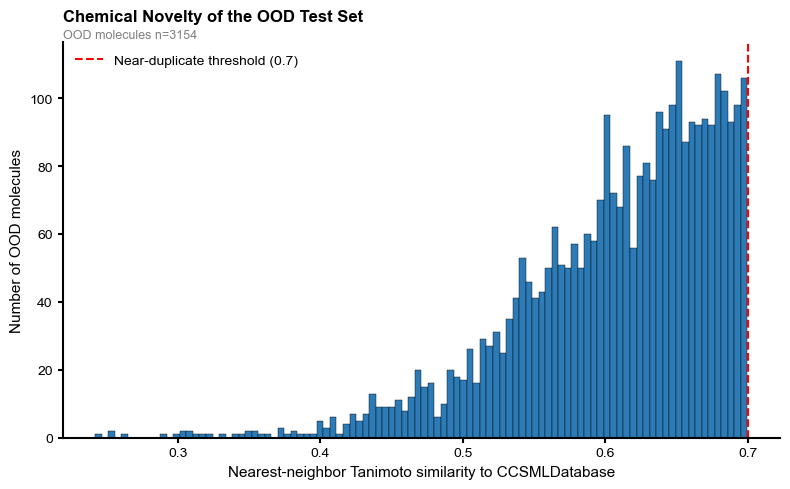

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(nn_similarity, bins=100, color="#2c7bb6", edgecolor="black", linewidth=0.3)
ax.axvline(
    NEAR_DUPLICATE_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
    label=f"Near-duplicate threshold ({NEAR_DUPLICATE_THRESHOLD})",
)
ax.legend(frameon=False)

ax.set_xlabel("Nearest-neighbor Tanimoto similarity to CCSMLDatabase")
ax.set_ylabel("Number of OOD molecules")
ax.set_title("Chemical Novelty of the OOD Test Set", loc="left", fontweight="bold", pad=15)
ax.text(0, 1.01, f"OOD molecules n={len(nn_similarity)}",
        transform=ax.transAxes, fontsize=9, color="gray")

plt.tight_layout()
plt.show()